In [ ]:
# p: Non Seasonal AR
# d: Non seasonal diff
# q: Non seasonal MA

#P: Seasonal AR
#D: Seasonal diff
#Q: Seasonal AR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


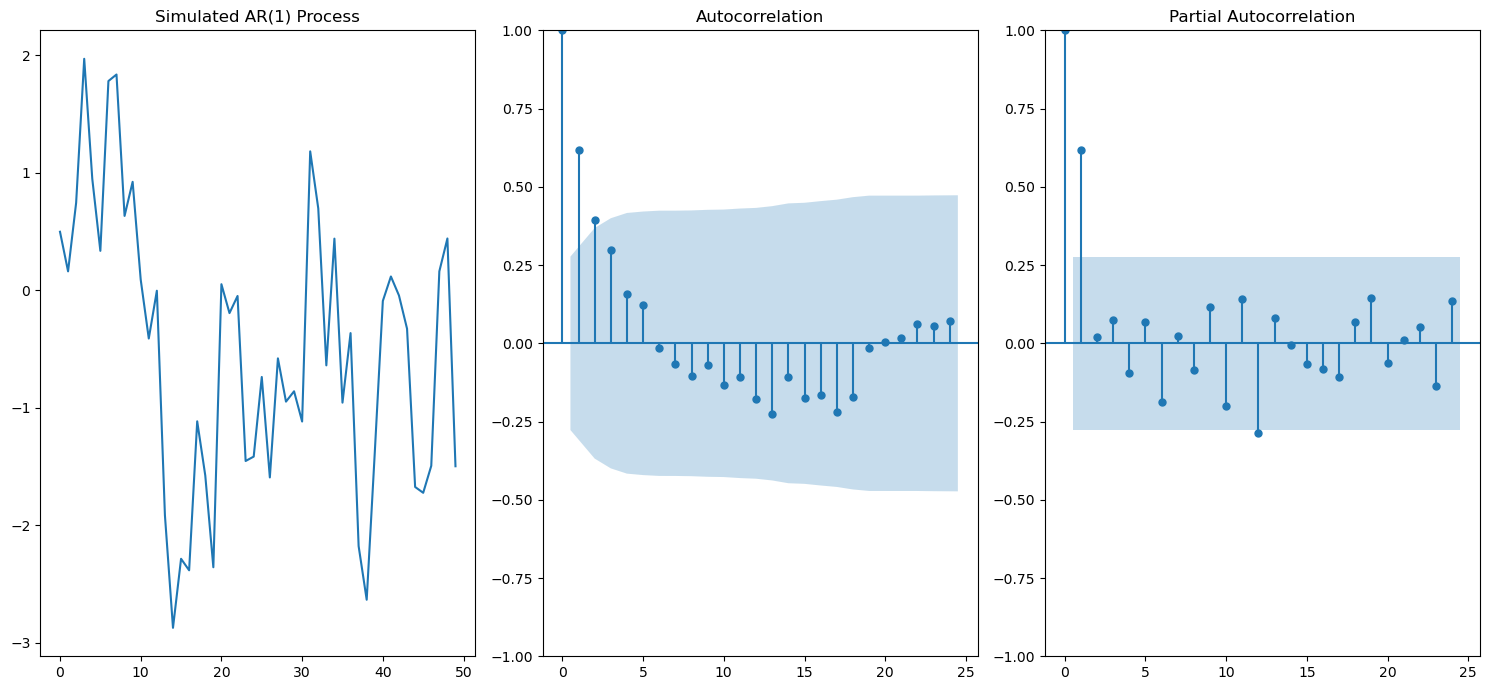

In [ ]:
#2.1
# 1. Define parameters
phi_1 = 0.6
ar = np.array([1, -phi_1]) # AR polynomial: [1, -0.6]
ma = np.array([1])         # MA polynomial: [1]

# 2. Simulate the process (e.g., 300 observations)
np.random.seed(42) # For reproducibility
y = arma_generate_sample(ar, ma, nsample=50)

# 3. Plotting (as requested in instructions)
fig, axes = plt.subplots(1, 3, figsize=(15,7))

# Time Series Plot
axes[0].plot(y)
axes[0].set_title("Simulated AR(1) Process")

# ACF Plot (up to lag 24 to see seasonal behavior)
plot_acf(y, lags=24, ax=axes[1])

# PACF Plot
plot_pacf(y, lags=24, ax=axes[2])

plt.tight_layout()
plt.show()

The AR(1) model is non-seasonal 
where the AR component is -0.6 Therefore, we observe in the ACF plot that the observation at t=1 has a value of 0.6 which means that the observation at t=0 is 60% correlated with observation at t=1. There is a exponential decay in correlation.

We observe the same for the PACF at t=0 and t=1. However at t=2, we see that there is no correlation left because information in the timestep t=1, which is between t=0 and t=2, is removed.

The correlations in the blue zone are white noise.



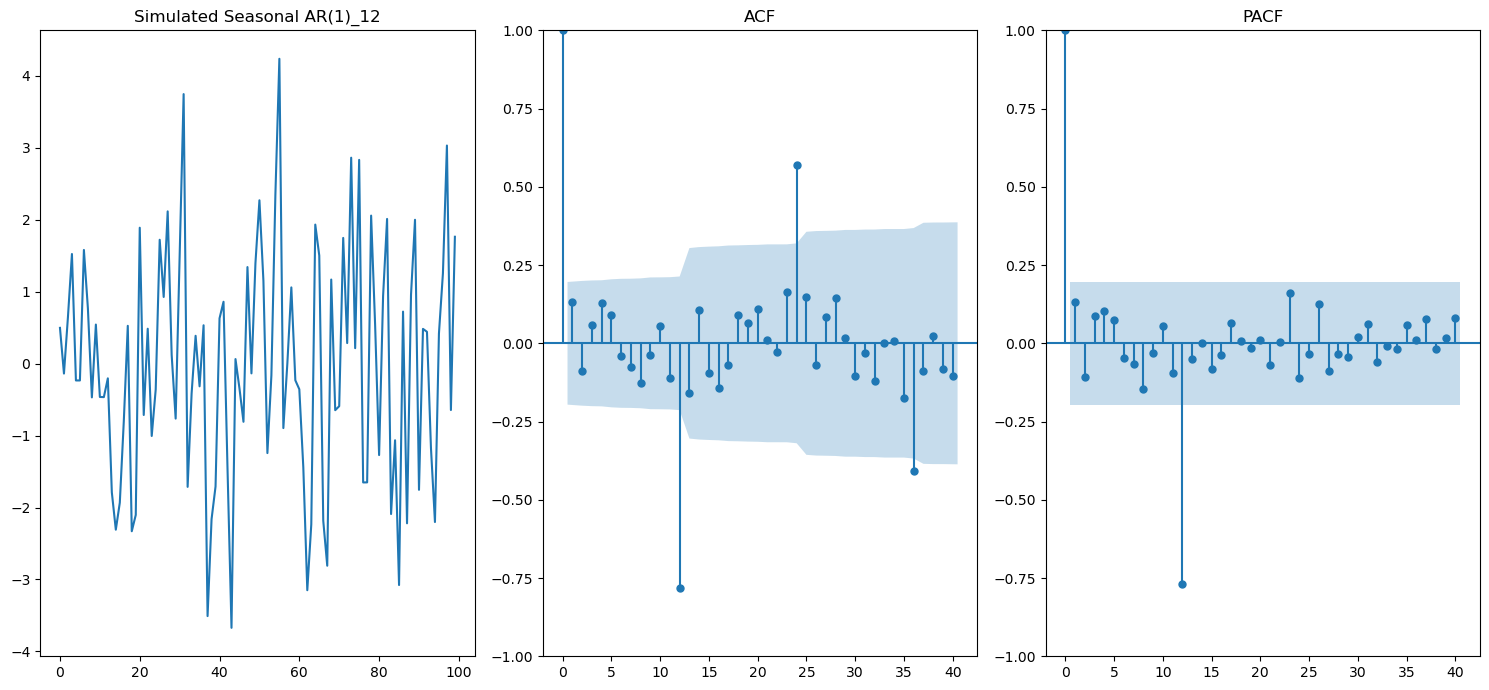

In [ ]:

# Model: (0,0,0) x (1,0,0)_12 with Phi_1 = -0.9
phi_seasonal = -0.9
# Create the AR polynomial: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -(-0.9)]
ar = np.zeros(13)
ar[0] = 1
ar[12] = -phi_seasonal  # Sign is flipped for arma_generate_sample

ma = np.array([1])

# 2. Simulate
np.random.seed(42)
y = arma_generate_sample(ar, ma, nsample=100)

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

axes[0].plot(y)
axes[0].set_title("Simulated Seasonal AR(1)_12")

# Look at 50 lags to see the seasonal spikes at 12, 24, 36, 48
plot_acf(y, lags=40, ax=axes[1], title="ACF")
plot_pacf(y, lags=40, ax=axes[2], title="PACF")

plt.tight_layout()
plt.show()

The AR(1) model here is seasonal where the AR term is 1. In the ACF plot, we see that there are spikes correlation spikes at t=12, t=24 and t=36 for the time window which makes sense since the model is seasonal and there is correlation between t and t-12. For the PACF model, also see negative correlation between t and t-12 since phi_1 = -0.9. The other observations are simply white noise. 